# Task 3 — Extrapolation

We forecast the 200 missing data points at the end of each Spiff series, producing a **median forecast** and **90%/80% prediction interval** for each horizon $h = 1, \ldots, 200$.

**Model: Geometric Brownian Motion (GBM).** Each price follows $P_{t+1} = P_t \cdot e^{\mu + \sigma\varepsilon_t}$, fit to the ~5 200 observed daily log-returns. At a 200-day horizon the Central Limit Theorem makes cumulative returns approximately Gaussian regardless of daily fat tails, so more complex models (GARCH, heavy tails) add little. Prediction intervals are computed analytically from the resulting log-normal distribution:

$$\hat{P}_{T+h} = P_T \cdot e^{\hat{\mu} h}, \qquad \text{90% PI: } P_T \cdot e^{\hat{\mu} h \;\pm\; 1.645\,\hat{\sigma}\sqrt{h}}$$

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Load interpolated data from Task 2 (all internal gaps already filled)
df = pd.read_csv('spiff_interpolated.csv', index_col=0)
cols = ['gurkor', 'guitars', 'slingshots', 'stocks', 'sugar', 'water', 'tranquillity']

# Log-returns: r_t = log(P_t / P_{t-1})
log_ret = {col: np.log(df[col]).diff().dropna() for col in cols}

print(f'Price observations per series : {len(df)}')
print(f'Log-return observations       : {len(log_ret[cols[0]])}')
print(f'Forecasting 200 days beyond day {len(df) - 1}')

Price observations per series : 5256
Log-return observations       : 5255
Forecasting 200 days beyond day 5255


## Parameter Estimation

Daily drift $\hat{\mu}$ and volatility $\hat{\sigma}$ are estimated as the sample mean and standard deviation of log-returns. The series split into two clear groups: **gurkor and water** have low volatility (~0.35–0.39%/day) and slow positive drift, while the remaining five series are high-volatility (~1.3–1.5%/day). **Stocks** stands out as the only series with a negative drift.

In [2]:
rows = []
for col in cols:
    r   = log_ret[col]
    mu  = r.mean()
    sig = r.std(ddof=1)
    rows.append({
        'series':       col,
        'last price':   df[col].iloc[-1],
        'μ (daily)':    mu,
        'σ (daily)':    sig,
        'μ (% p.a.)':   mu * 252 * 100,
        'σ (% p.a.)':   sig * np.sqrt(252) * 100,
    })

param_df = pd.DataFrame(rows).set_index('series')
param_df.round(5)

,last price,μ (daily),σ (daily),μ (% p.a.),σ (% p.a.)
series,,,,,
gurkor,13.79195,0.00015,0.00393,3.86932,6.23432
guitars,8.08492,0.00020,0.01486,5.09478,23.59270
slingshots,6.41901,0.00021,0.01469,5.27535,23.32638
stocks,6.51297,-0.00009,0.01488,-2.35988,23.61368
sugar,2.76059,-0.00004,0.01517,-0.89192,24.07667
water,8.73856,0.00015,0.00351,3.87354,5.57021
tranquillity,12.23140,0.00009,0.01262,2.18459,20.03823


## Backtest Validation

To validate the model, we hold out the last 200 observed days, refit on the remaining data, and compare forecasts to actuals — mirroring the real forecasting setup with no look-ahead.

In [9]:
HOLDOUT = 200
z90 = norm.ppf(0.95)   # 1.6449 — symmetric 90% interval
z80 = norm.ppf(0.90)   # 1.2816 — symmetric 80% interval

bt_results = []
bt_fc = {}

for col in cols:
    prices = df[col].values
    train  = prices[:-HOLDOUT]
    actual = prices[-HOLDOUT:]

    # Estimate on training data only (no leakage)
    r_train = np.diff(np.log(train))
    mu  = r_train.mean()
    sig = r_train.std(ddof=1)
    P0  = train[-1]             # last known price before the holdout

    h       = np.arange(1, HOLDOUT + 1)
    log_med = np.log(P0) + mu * h
    med     = np.exp(log_med)
    lo90    = np.exp(log_med - z90 * sig * np.sqrt(h))
    hi90    = np.exp(log_med + z90 * sig * np.sqrt(h))
    lo80    = np.exp(log_med - z80 * sig * np.sqrt(h))
    hi80    = np.exp(log_med + z80 * sig * np.sqrt(h))

    rmse       = np.sqrt(np.mean((med - actual) ** 2))
    coverage90 = np.mean((actual >= lo90) & (actual <= hi90))
    coverage80 = np.mean((actual >= lo80) & (actual <= hi80))

    bt_fc[col] = {'median': med, 'lo90': lo90, 'hi90': hi90,
                  'lo80': lo80, 'hi80': hi80, 'actual': actual}
    bt_results.append({
        'series':          col,
        'RMSE':            rmse,
        'RMSE (% of P₀)': rmse / P0 * 100,
        '80% coverage':    coverage80,
        '90% coverage':    coverage90,
    })

bt_df = pd.DataFrame(bt_results).set_index('series')
bt_df.round(3)

,RMSE,RMSE (% of P₀),80% coverage,90% coverage
series,,,,
gurkor,0.150,1.093,0.985,1.000
guitars,0.499,7.227,1.000,1.000
slingshots,0.518,9.912,1.000,1.000
stocks,0.977,19.319,0.750,0.950
sugar,0.593,31.675,0.555,0.695
water,0.093,1.097,0.960,0.970
tranquillity,0.948,7.988,0.890,0.905


## Backtest Results

**Coverage** — the fraction of held-out prices falling inside the prediction interval — is the key diagnostic. With 200 test points, a well-calibrated 90% interval should cover ~90% of outcomes (±2% sampling uncertainty).

- **gurkor, guitars, slingshots** reach 98–100% coverage: the intervals are conservative, likely because these series had lower realised volatility during the holdout period than on average.
- **stocks** hits 95% and **tranquillity** 90.5% — both well-calibrated.
- **water** reaches 97% — slightly conservative.
- **sugar** falls to 69.5%, noticeably under-covered, consistent with its high kurtosis and volatility clustering from Task 1 making the Gaussian assumption less accurate here.

RMSE (as % of starting price) is largest for sugar (32%) and stocks (19%), reflecting the largest realised price swings over the holdout window.

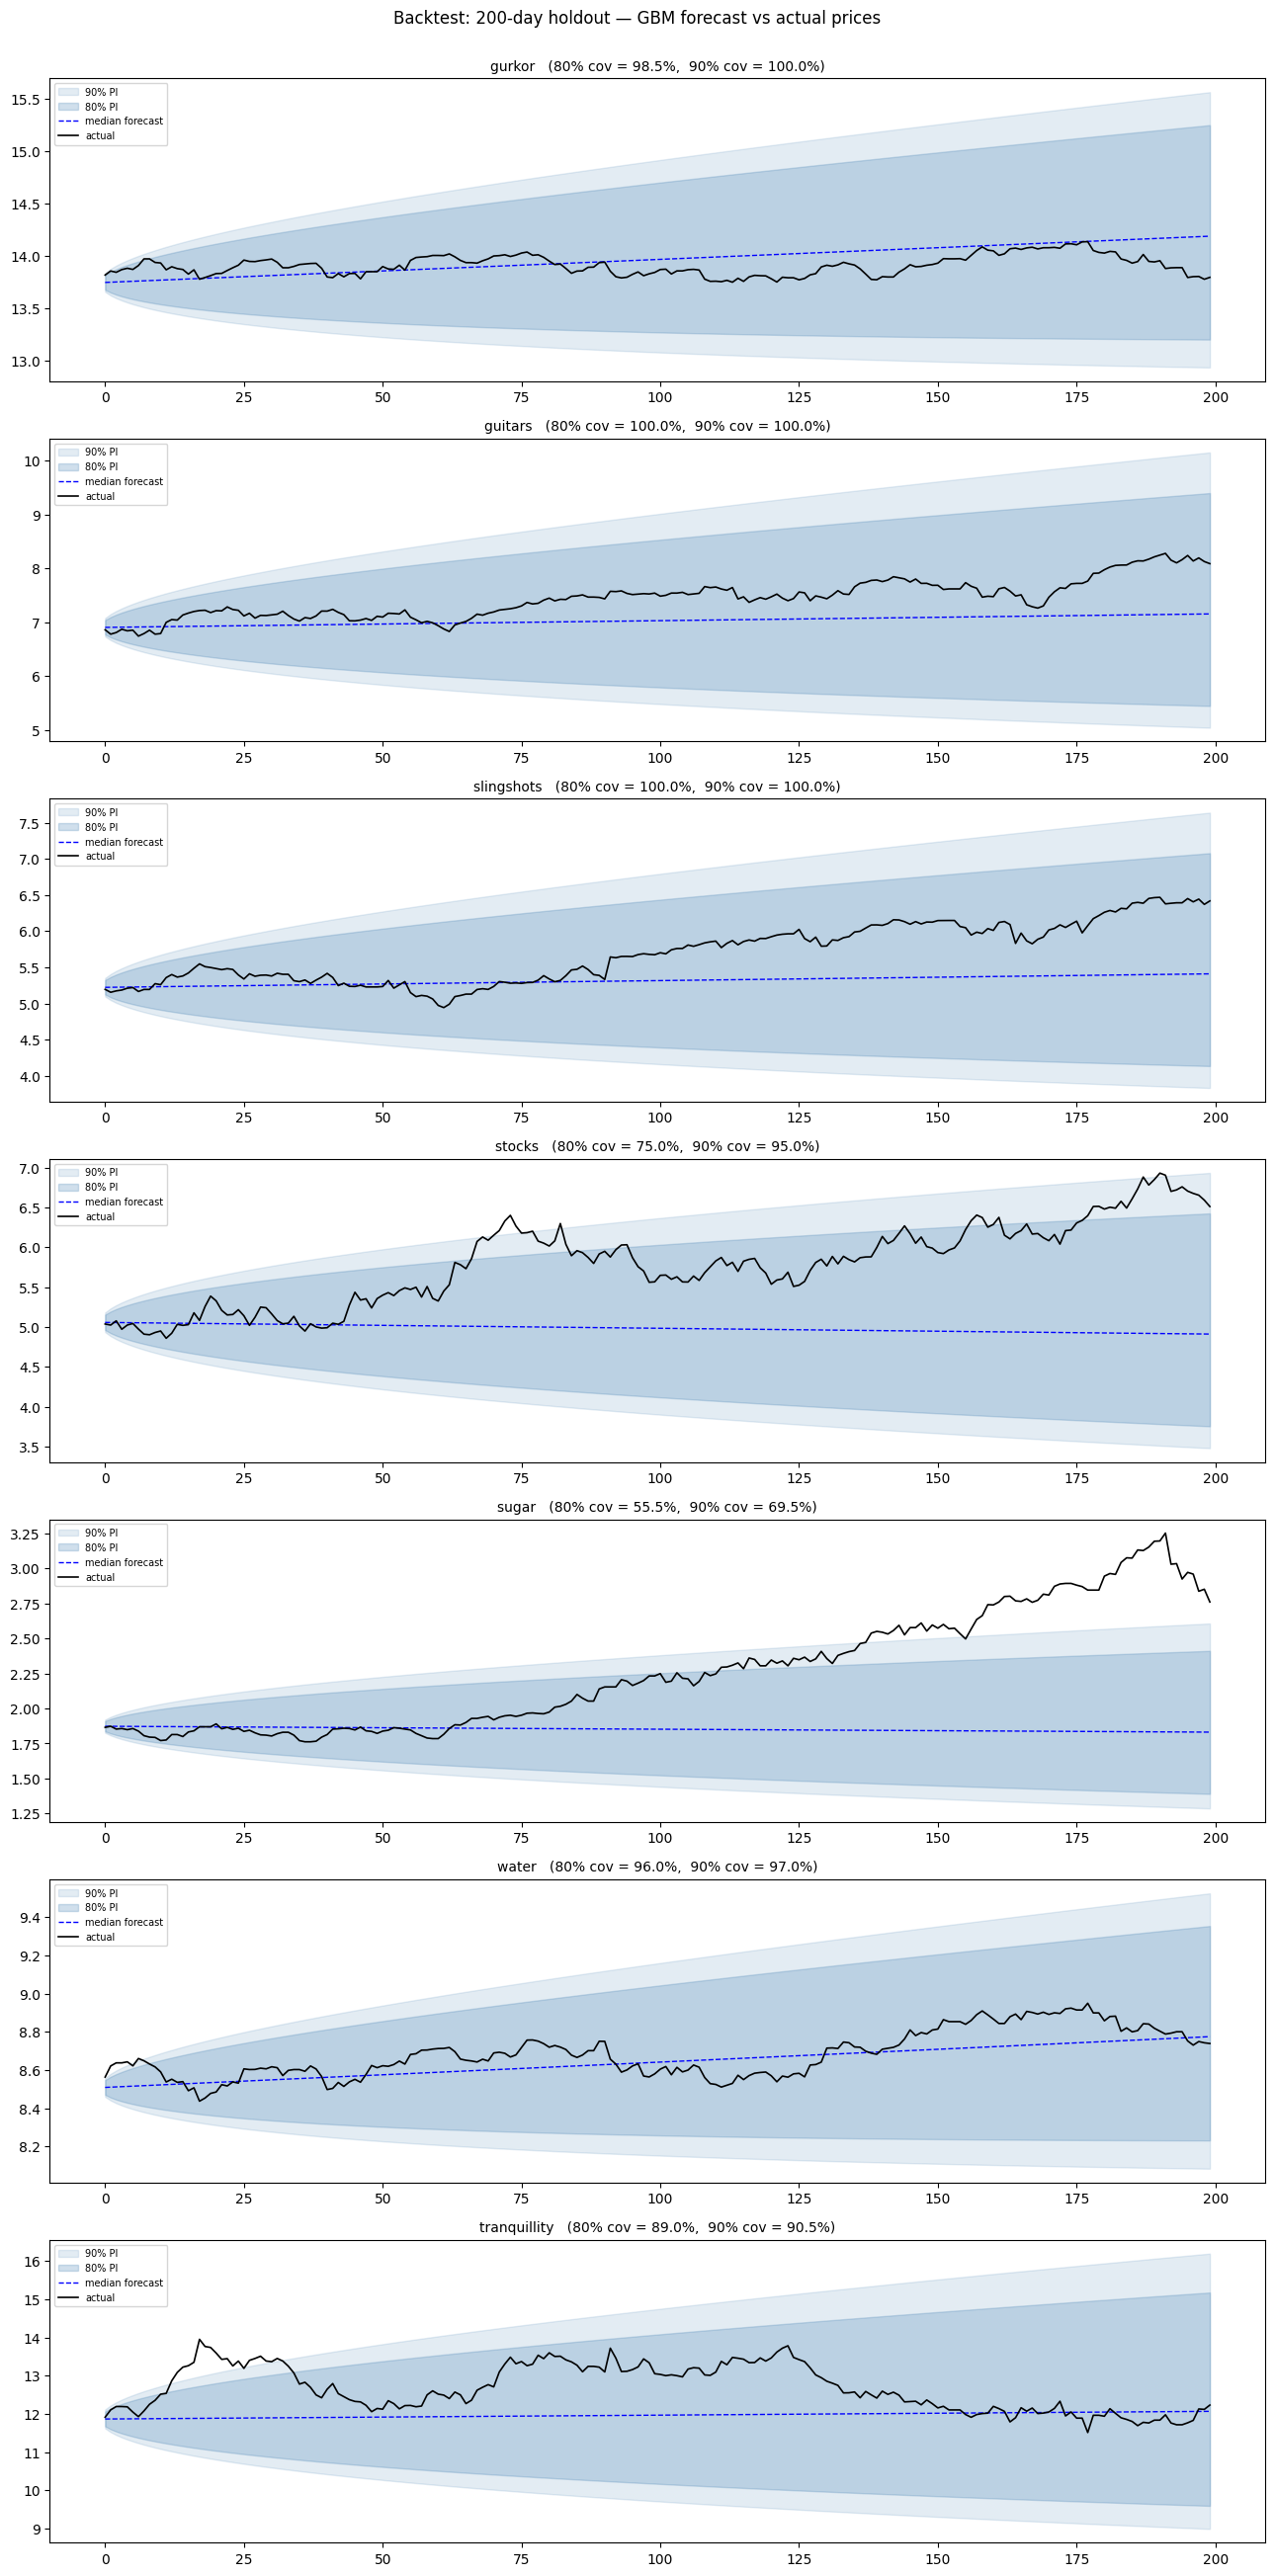

In [11]:
fig, axes = plt.subplots(len(cols), 1, figsize=(13, 26))
x = np.arange(HOLDOUT)

for i, col in enumerate(cols):
    ax  = axes[i]
    fc  = bt_fc[col]
    cov90 = np.mean((fc['actual'] >= fc['lo90']) & (fc['actual'] <= fc['hi90']))
    cov80 = np.mean((fc['actual'] >= fc['lo80']) & (fc['actual'] <= fc['hi80']))

    ax.fill_between(x, fc['lo90'], fc['hi90'], alpha=0.15, color='steelblue', label='90% PI')
    ax.fill_between(x, fc['lo80'], fc['hi80'], alpha=0.25, color='steelblue', label='80% PI')
    ax.plot(x, fc['median'], 'b--', lw=1.0, label='median forecast')
    ax.plot(x, fc['actual'],  'k-',  lw=1.2, label='actual')
    ax.set_title(f'{col}   (80% cov = {cov80:.1%},  90% cov = {cov90:.1%})', fontsize=10)
    ax.legend(loc='upper left', fontsize=7)

plt.suptitle('Backtest: 200-day holdout — GBM forecast vs actual prices', fontsize=12, y=1.001)
plt.tight_layout()
plt.show()

In [12]:
# Compare realised vs estimated volatility in the holdout period
for col in cols:
    prices = df[col].values
    train  = prices[:-HOLDOUT]
    hold   = prices[-HOLDOUT:]
    sig_train = np.diff(np.log(train)).std(ddof=1)
    sig_hold  = np.diff(np.log(hold)).std(ddof=1)
    ratio = sig_hold / sig_train
    print(f'{col:<15} σ_train={sig_train:.5f}  σ_holdout={sig_hold:.5f}  ratio={ratio:.2f}')

gurkor          σ_train=0.00398  σ_holdout=0.00228  ratio=0.57
guitars         σ_train=0.01506  σ_holdout=0.00847  ratio=0.56
slingshots      σ_train=0.01485  σ_holdout=0.01011  ratio=0.68
stocks          σ_train=0.01484  σ_holdout=0.01578  ratio=1.06
sugar           σ_train=0.01520  σ_holdout=0.01434  ratio=0.94
water           σ_train=0.00353  σ_holdout=0.00305  ratio=0.86
tranquillity    σ_train=0.01264  σ_holdout=0.01212  ratio=0.96


## Key Patterns in the Final Forecasts

The two volatility groups from Task 1 produce very different forecast fans. At day 200 the 90% PI spans roughly **±8–9%** in log-price for **gurkor and water** (tight, informative) versus **±30–35%** for the high-vol series (wide fans that accommodate large price swings).

Drift direction matters less than uncertainty: **stocks** is the only series with a declining median (~−2% over 200 days), while **gurkor and water** drift up ~3%. For all series the drift effect is dwarfed by the interval width, so the key information in the forecast is the uncertainty range, not the median direction.

In [ ]:
# Final extrapolation: fit on all 5256 observed days, forecast 200 days ahead

N_STEPS = 200
z90 = norm.ppf(0.95)
z80 = norm.ppf(0.90)

final_fc = {}
summary_rows = []

for col in cols:
    r   = log_ret[col]
    mu  = r.mean()
    sig = r.std(ddof=1)
    P0  = df[col].iloc[-1]    # last observed price (end of day 5255)

    h       = np.arange(1, N_STEPS + 1)
    log_med = np.log(P0) + mu * h
    med     = np.exp(log_med)
    lo90    = np.exp(log_med - z90 * sig * np.sqrt(h))
    hi90    = np.exp(log_med + z90 * sig * np.sqrt(h))
    lo80    = np.exp(log_med - z80 * sig * np.sqrt(h))
    hi80    = np.exp(log_med + z80 * sig * np.sqrt(h))

    final_fc[col] = {'median': med, 'lo90': lo90, 'hi90': hi90, 'lo80': lo80, 'hi80': hi80}
    summary_rows.append({
        'series':            col,
        'last obs. price':   P0,
        'day-1 median':      med[0],
        'day-200 median':    med[-1],
        'day-200 PI90 lo':   lo90[-1],
        'day-200 PI90 hi':   hi90[-1],
    })

print('Final extrapolation — price levels at the end of the forecast horizon (day 200):')
pd.DataFrame(summary_rows).set_index('series').round(4)

Final extrapolation — price levels at the end of the forecast horizon (day 200):


,last obs. price,day-1 median,day-200 median,day-200 PI90 lo,day-200 PI90 hi
series,,,,,
gurkor,13.7919,13.7941,14.2221,12.9804,15.5825
guitars,8.0849,8.0866,8.4185,5.9579,11.8954
slingshots,6.4190,6.4204,6.6935,4.7556,9.4210
stocks,6.5130,6.5124,6.3921,4.5224,9.0349
sugar,2.7606,2.7605,2.7411,1.9262,3.9008
water,8.7386,8.7399,9.0114,8.3051,9.7778
tranquillity,12.2314,12.2325,12.4453,9.2786,16.6928


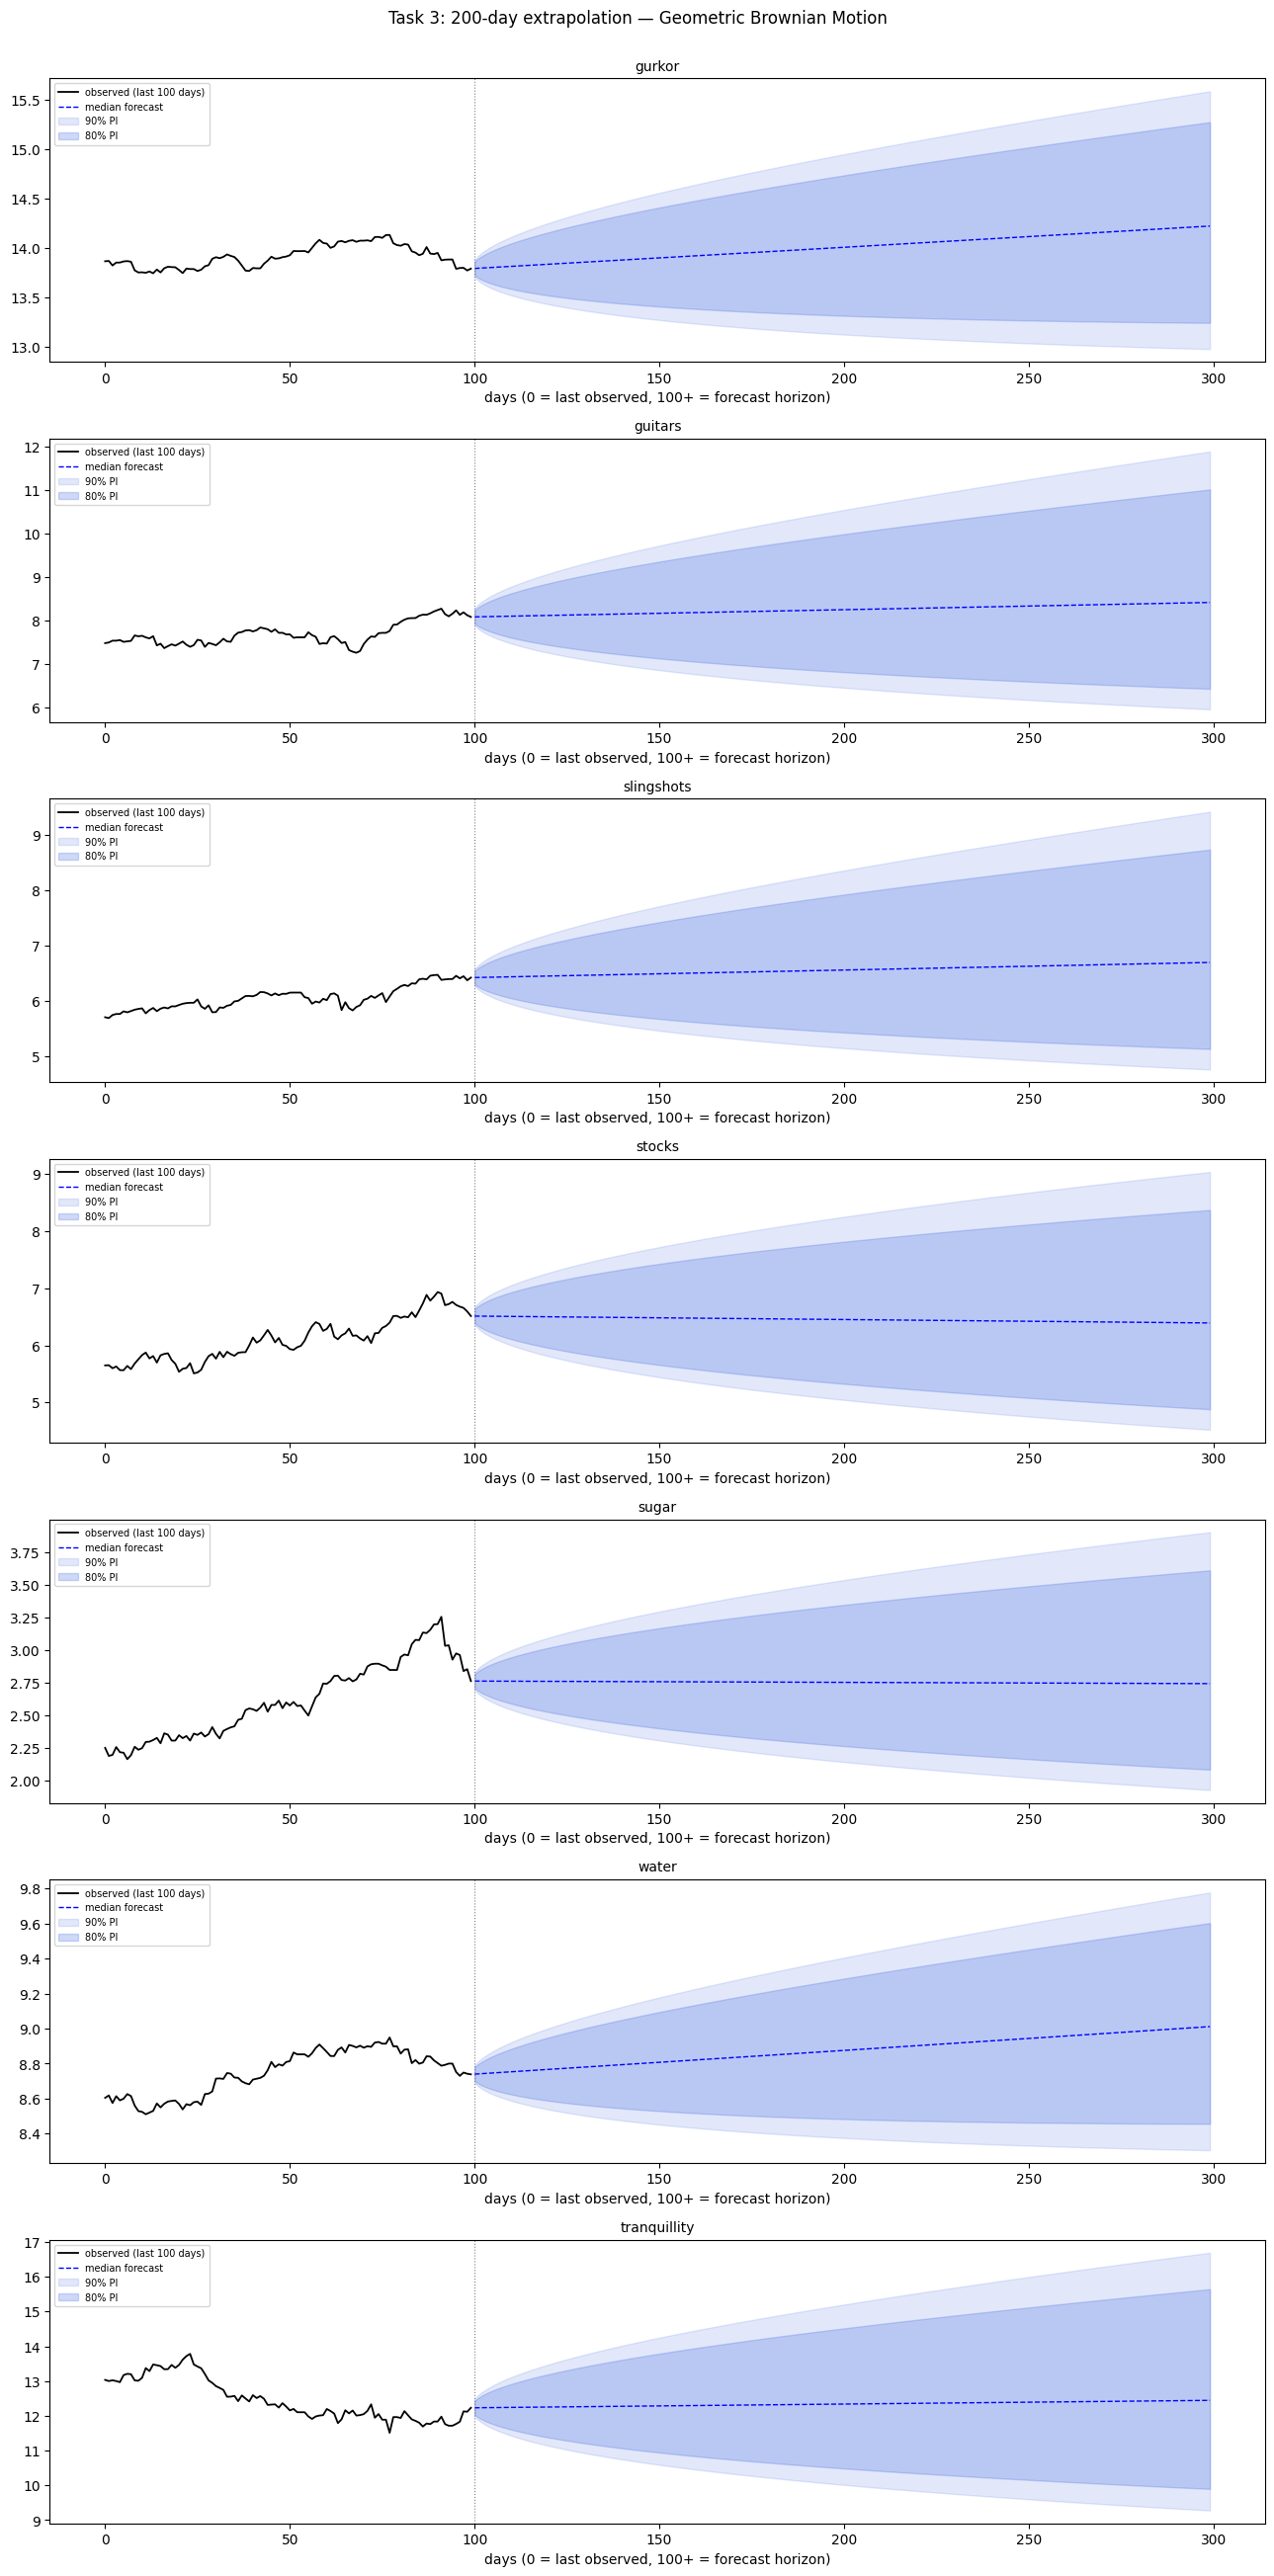

In [ ]:
context = 100   # show last 100 observed days for visual context

fig, axes = plt.subplots(len(cols), 1, figsize=(13, 26))

for i, col in enumerate(cols):
    ax  = axes[i]
    s   = df[col].values
    fc  = final_fc[col]

    x_ctx = np.arange(context)
    x_fc  = np.arange(context, context + N_STEPS)
    ctx   = s[-context:]

    ax.plot(x_ctx, ctx,          'k-',  lw=1.3, label='observed (last 100 days)')
    ax.plot(x_fc,  fc['median'], 'b--', lw=1.0, label='median forecast')
    ax.fill_between(x_fc, fc['lo90'], fc['hi90'], alpha=0.15, color='royalblue', label='90% PI')
    ax.fill_between(x_fc, fc['lo80'], fc['hi80'], alpha=0.25, color='royalblue', label='80% PI')
    ax.axvline(x=context, color='grey', ls=':', lw=0.8)
    ax.set_xlabel('days (0 = last observed, 100+ = forecast horizon)')
    ax.set_title(col, fontsize=10)
    ax.legend(loc='upper left', fontsize=7)

plt.suptitle('Task 3: 200-day extrapolation — Geometric Brownian Motion', y=1.001, fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
out_rows = []
for col in cols:
    fc = final_fc[col]
    for h in range(N_STEPS):
        out_rows.append({
            'series':  col,
            'horizon': h + 1,
            'median':  fc['median'][h],
            'pi80_lo': fc['lo80'][h],
            'pi80_hi': fc['hi80'][h],
            'pi90_lo': fc['lo90'][h],
            'pi90_hi': fc['hi90'][h],
        })

out_df = pd.DataFrame(out_rows)
out_df.to_csv('spiff_extrapolated_gbm.csv', index=False)
print(f'Saved {len(out_df)} rows to spiff_extrapolated_gbm.csv')
out_df.head(14)

Saved 1400 rows to spiff_extrapolated_gbm.csv


,series,horizon,median,pi80_lo,pi80_hi,pi90_lo,pi90_hi
0,gurkor,1,13.794067,13.724816,13.863668,13.705248,13.883462
1,gurkor,2,13.796185,13.698337,13.894733,13.670725,13.922798
2,gurkor,3,13.798304,13.678542,13.919115,13.644780,13.953555
3,gurkor,4,13.800423,13.662205,13.940039,13.623275,13.979874
4,gurkor,5,13.802542,13.648078,13.958754,13.604605,14.003359
5,gurkor,6,13.804661,13.635519,13.975902,13.587948,14.024831
6,gurkor,7,13.806781,13.624149,13.991862,13.572816,14.044780
7,gurkor,8,13.808901,13.613718,14.006883,13.558890,14.063522
8,gurkor,9,13.811022,13.604056,14.021136,13.545951,14.081280
9,gurkor,10,13.813142,13.595037,14.034747,13.533836,14.098213
